In [1]:
import sys, os
sys.path.insert(0, os.path.dirname(os.getcwd()))

from scripts.s1_rvl import compute_rvl, compute_rvl_gamma
import numpy as np
from matplotlib import pyplot as plt
import os
import xarray as xr
from scripts.rvl_pipeline import run_all_bursts, plot_comparison, write_burst_kml, plot_pipeline_steps
from scripts.plot_era5_influence import plot_wind_influence, plot_wave_influence 

In [2]:
SUBSWATH    = 'iw1'
BURST_IDX   = 3
POL         = 'vv'
SCENE_IDX   = 3

In [7]:
os.path.dirname(os.getcwd())

'/home/oscipal'

In [ ]:
# ── Data paths ──────────────────────────────────────────────────────────────
ROOT        = os.path.dirname(os.getcwd())          # repo root
DATA        = os.path.join(ROOT, 'ocean_current_retrieval/data')
SCENE       = f"scene{SCENE_IDX}"

SLC_SAFE    = os.path.join(DATA, 'sentinel-1', SCENE,
    'S1A_IW_SLC.SAFE')
OCN_SAFE    = os.path.join(DATA, 'sentinel-1', SCENE,
    'S1A_IW_OCN.SAFE')
AUX_CAL     = os.path.join(DATA, 'sentinel-1',
    'S1A_AUX_CAL_V20190228T092500_G20240327T102320.SAFE')
POEORB      = os.path.join(DATA, 'sentinel-1',
    'S1A_OPER_AUX_POEORB_OPOD_20260225T070420_V20260204T225942_20260206T005942.EOF')
ERA5_WIND   = os.path.join(DATA, 'era5_data', SCENE, 'era5_wind.nc')
ERA5_WAVE   = os.path.join(DATA, 'era5_data', SCENE, 'era5_wave.nc')
GLO12       = os.path.join(DATA, 'era5_data', SCENE,
    'glo12.nc')

print('All paths exist:', all(os.path.exists(p)
    for p in [SLC_SAFE, AUX_CAL, POEORB, ERA5_WIND, ERA5_WAVE, GLO12]))

In [ ]:
results = run_all_bursts(SLC_SAFE, SUBSWATH, POEORB, AUX_CAL, OCN_SAFE, ERA5_WIND, ERA5_WAVE, GLO12, POL)

In [12]:
result_scene1 = run_analysis(1, SUBSWATH, BURST_IDX, POL)
#result_scene2 = run_analysis(2, SUBSWATH, BURST_IDX, POL)
#result_scene3 = run_analysis(3, SUBSWATH, BURST_IDX, POL)

All paths exist: True
Processing 10 bursts for IW1 …

─── Burst 0 / 9 ───────────────────────────
Loading annotation for IW1 burst 0 …
  Burst time : 2026-02-05 16:52:51.616345+00:00
  PRF        : 486.486 Hz
  Wavelength : 5.55 cm
  γ_amb=0.00000  f_sideband=0.000 Hz
Step I: deramping …
Step II: estimating p0, p1 …
Step III: geometry subtraction …
  v_r median: +0.1895 m/s
Step V: geolocation …
  Heading: -13.3°   Look azimuth: 76.7°
Loading ERA5 Stokes drift …
  v_stokes range: [-0.0428, -0.0208] m/s
Loading ERA5 wind …
  v_wave range: [-0.1650, -0.0352] m/s
Loading OCN …
  v_miss_ocn range: [0.2334, 0.3910] m/s
Loading GLO12 …
  vs GLO12 (no mispointing):  bias=-0.1767  RMSE=0.2141  r=-0.2077
  vs GLO12 (OCN mispointing):  bias=+0.1171  RMSE=0.1510  r=-0.4851

─── Burst 1 / 9 ───────────────────────────
Loading annotation for IW1 burst 1 …
  Burst time : 2026-02-05 16:52:54.374902+00:00
  PRF        : 486.486 Hz
  Wavelength : 5.55 cm
  γ_amb=0.00000  f_sideband=0.000 Hz
Step I: der

Merging SAR …
Merging GLO12 …


c:\Users\ottos\Documents\Geomatik\2. Sem\ocean_current_retrieval\scripts\rvl_pipeline.py:1052: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


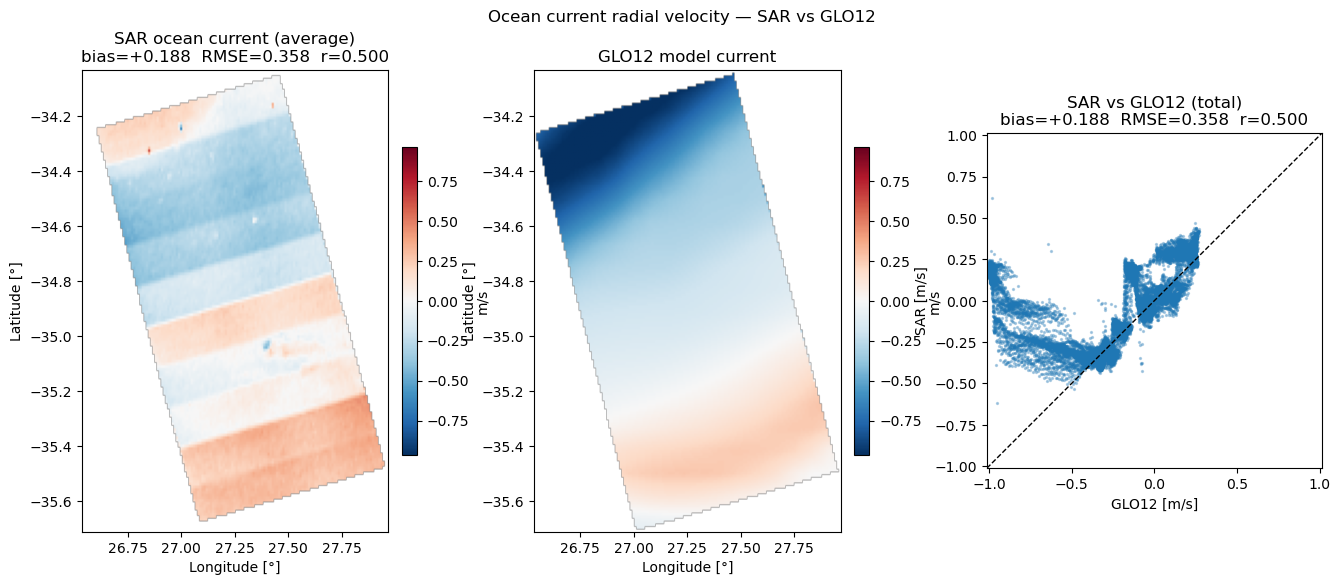


 Burst  bias [m/s]  RMSE [m/s]       r
────────────────────────────────────────
     0     +0.1690      0.1814  0.4309
     1     +0.0762      0.0997  -0.0701
     2     -0.0453      0.0788  0.1393
     3     +0.0169      0.0760  0.1225
     4     +0.3145      0.3182  -0.3459
     5     +0.0292      0.0562  -0.3320
     6     -0.0247      0.0662  -0.1412
     7     +0.0562      0.1291  0.1867
     8     +0.3972      0.4554  -0.5608
     9     +0.9534      0.9776  -0.7161
────────────────────────────────────────
 total     +0.1882      0.3579  0.4999


In [17]:
plot_comparison(result_scene1, overlap='average')

Merging SAR …
Merging GLO12 …


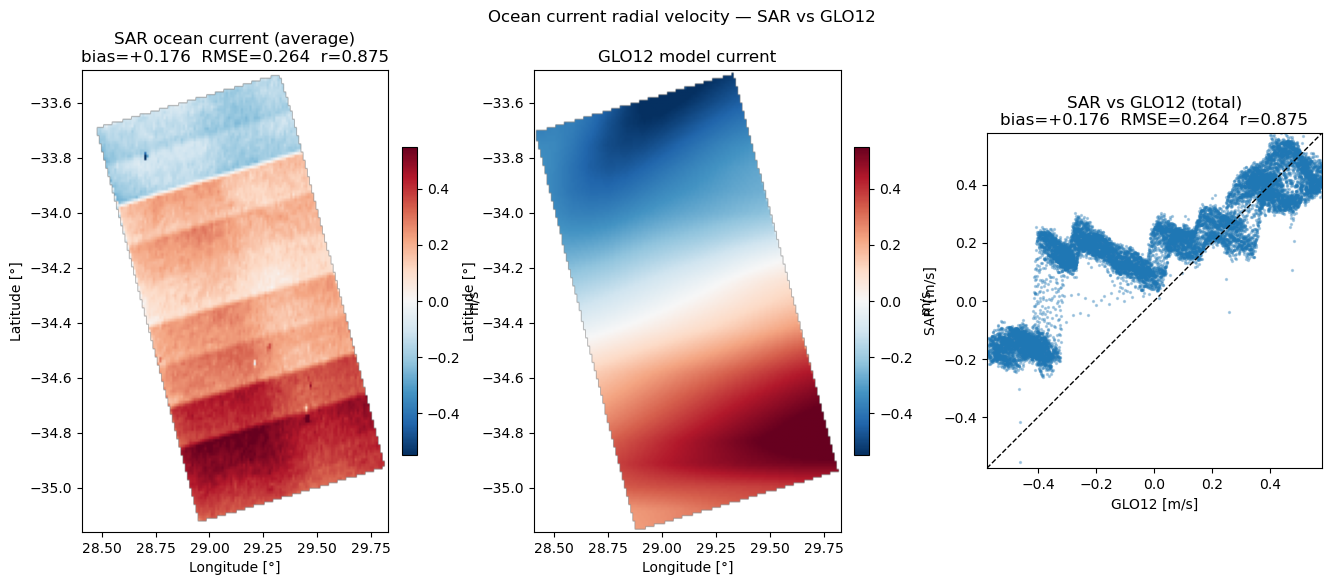


 Burst  bias [m/s]  RMSE [m/s]       r
────────────────────────────────────────
     0     -0.0407      0.1082  0.1989
     1     -0.0135      0.0956  -0.5201
     2     -0.0146      0.0880  -0.6102
     3     -0.0033      0.0829  -0.4446
     4     +0.1317      0.1485  -0.4757
     5     +0.1720      0.1860  -0.5063
     6     +0.4133      0.4185  -0.5313
     7     +0.4920      0.4964  -0.6584
     8     +0.2626      0.2731  -0.5212
     9     +0.3231      0.3305  0.0058
────────────────────────────────────────
 total     +0.1755      0.2638  0.8745


In [18]:
plot_comparison(result_scene2, overlap='average')

Merging SAR …
Merging GLO12 …


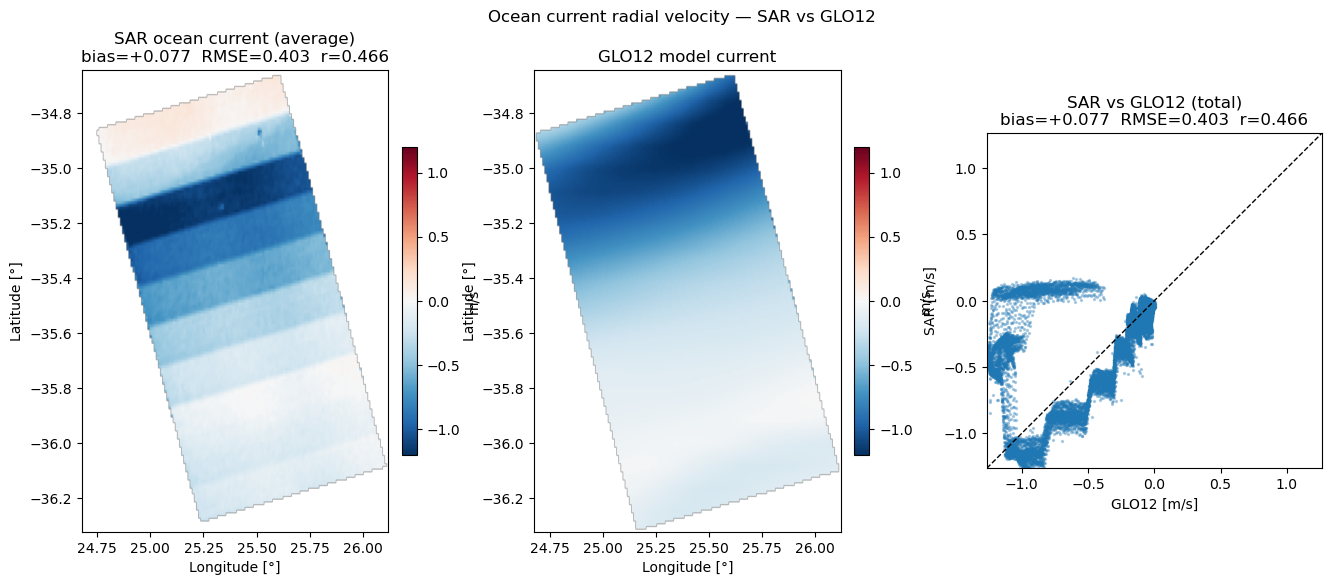


 Burst  bias [m/s]  RMSE [m/s]       r
────────────────────────────────────────
     0     +0.0333      0.0656  0.0175
     1     -0.0914      0.1050  0.3821
     2     +0.0230      0.0611  -0.2337
     3     -0.0519      0.0824  -0.6058
     4     -0.1201      0.1377  -0.4890
     5     -0.2267      0.2381  -0.0808
     6     -0.2191      0.2420  0.0235
     7     -0.1660      0.1986  -0.1321
     8     +0.7390      0.7453  0.4279
     9     +0.9305      0.9530  0.3610
────────────────────────────────────────
 total     +0.0773      0.4028  0.4662


In [19]:
plot_comparison(result_scene3, overlap='average')

In [ ]:
result_scene11 = run_analysis(1, SUBSWATH, BURST_IDX, POL, use_ocn_dc=True)
result_scene21 = run_analysis(2, SUBSWATH, BURST_IDX, POL, use_ocn_dc=True)
result_scene31 = run_analysis(3, SUBSWATH, BURST_IDX, POL, use_ocn_dc=True)

Merging SAR …
Merging GLO12 …


c:\Users\ottos\Documents\Geomatik\2. Sem\ocean_current_retrieval\scripts\rvl_pipeline.py:1052: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


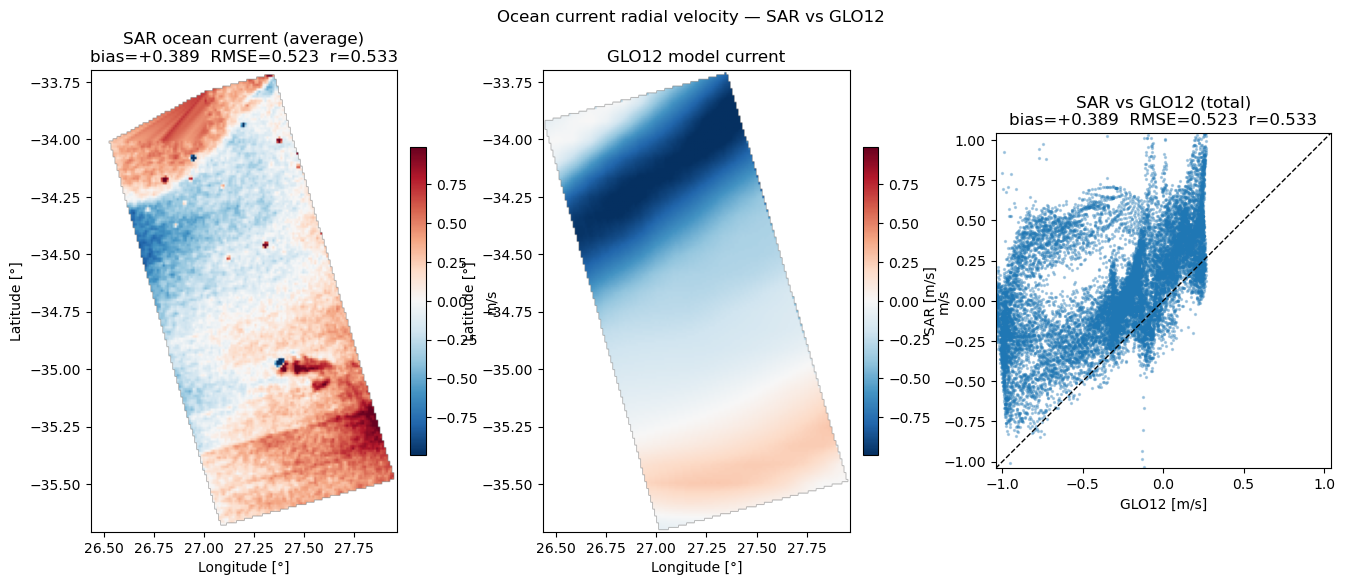


 Burst  bias [m/s]  RMSE [m/s]       r
────────────────────────────────────────
   ocn     +0.3808      0.5146  0.5506
────────────────────────────────────────
 total     +0.3893      0.5230  0.5325


In [20]:
plot_comparison(result_scene11, overlap='average')

Merging SAR …
Merging GLO12 …


c:\Users\ottos\Documents\Geomatik\2. Sem\ocean_current_retrieval\scripts\rvl_pipeline.py:1052: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


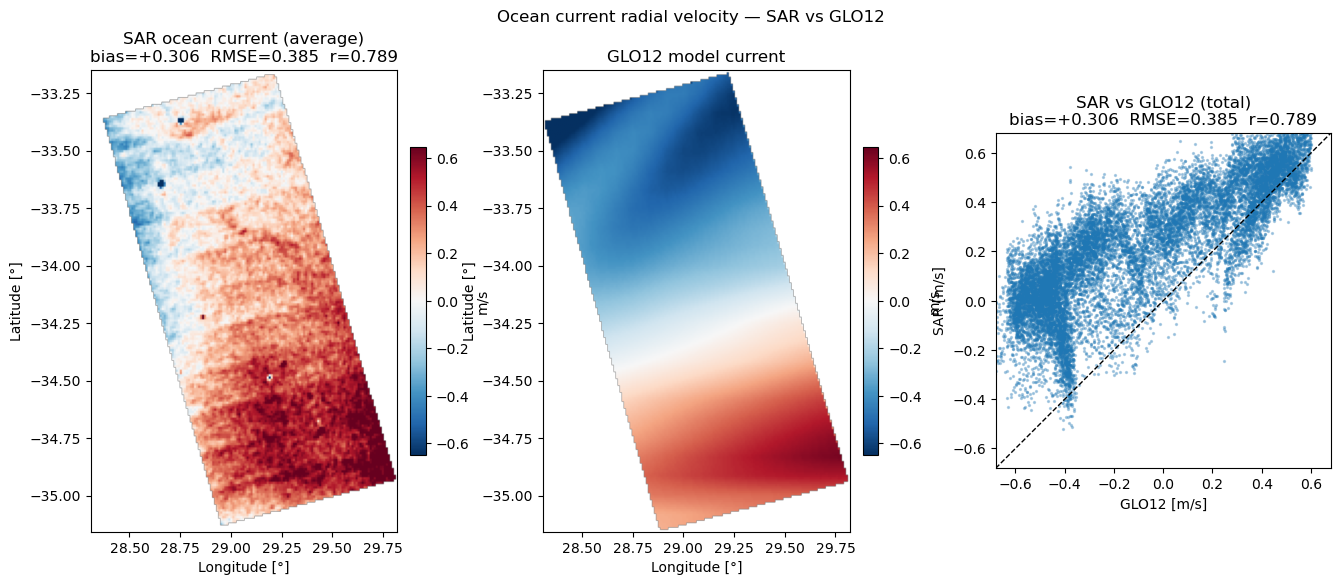


 Burst  bias [m/s]  RMSE [m/s]       r
────────────────────────────────────────
   ocn     +0.3099      0.3918  0.7787
────────────────────────────────────────
 total     +0.3057      0.3854  0.7887


In [21]:
plot_comparison(result_scene21, overlap='average')

Merging SAR …
Merging GLO12 …


c:\Users\ottos\Documents\Geomatik\2. Sem\ocean_current_retrieval\scripts\rvl_pipeline.py:1052: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


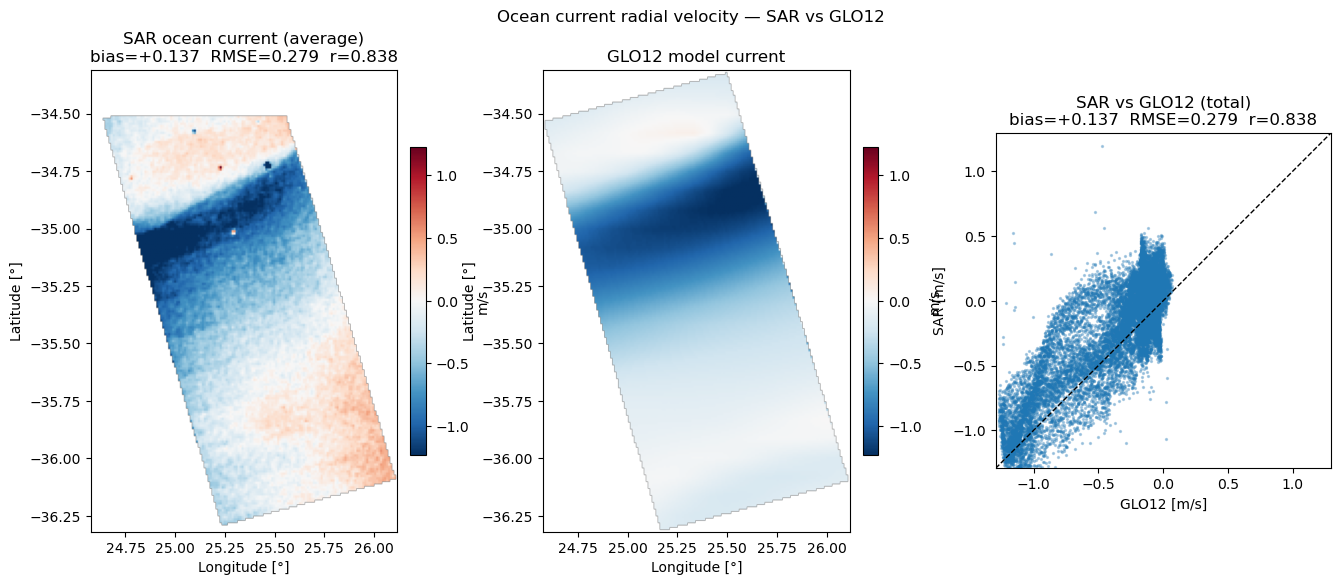


 Burst  bias [m/s]  RMSE [m/s]       r
────────────────────────────────────────
   ocn     +0.1445      0.2851  0.8362
────────────────────────────────────────
 total     +0.1373      0.2791  0.8382


In [22]:
plot_comparison(result_scene31, overlap='average')

In [ ]:
result_scene12 = run_analysis(1, SUBSWATH, BURST_IDX, POL, merge_first=True)
result_scene22 = run_analysis(2, SUBSWATH, BURST_IDX, POL, merge_first=True)
result_scene32 = run_analysis(3, SUBSWATH, BURST_IDX, POL, merge_first=True)

Merging SAR …
Merging GLO12 …


c:\Users\ottos\Documents\Geomatik\2. Sem\ocean_current_retrieval\scripts\rvl_pipeline.py:1052: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


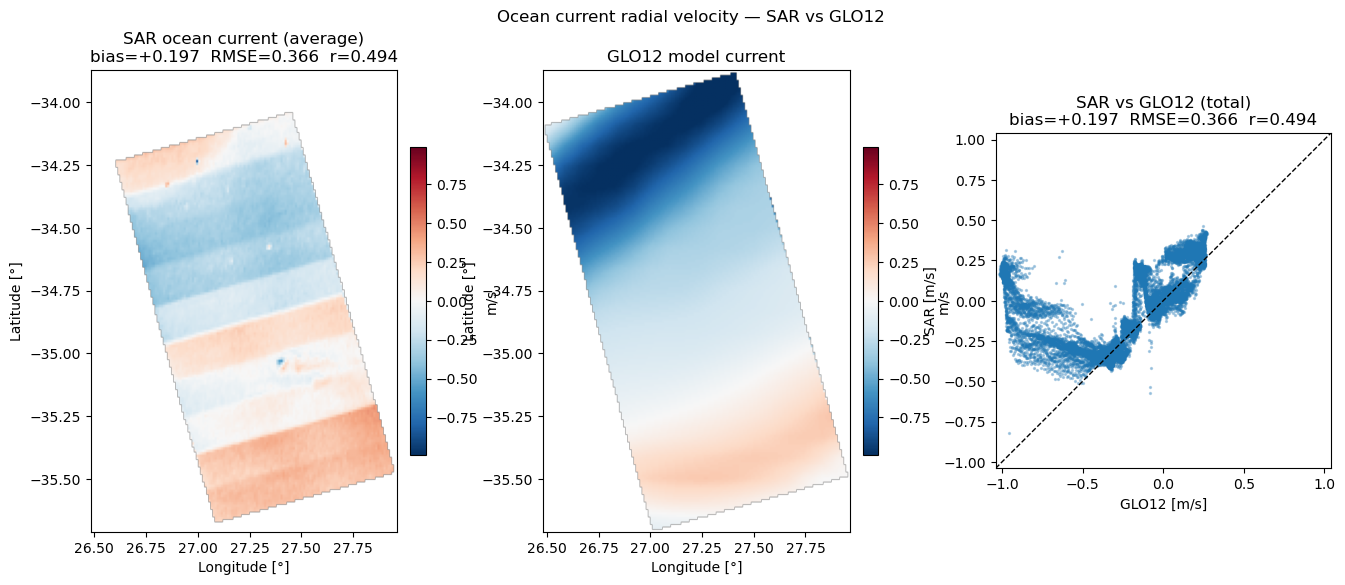


 Burst  bias [m/s]  RMSE [m/s]       r
────────────────────────────────────────
  merged     +0.2013      0.3732  0.4805
────────────────────────────────────────
 total     +0.1971      0.3664  0.4940


In [23]:
plot_comparison(result_scene12, overlap='average')

Merging SAR …
Merging GLO12 …


c:\Users\ottos\Documents\Geomatik\2. Sem\ocean_current_retrieval\scripts\rvl_pipeline.py:1052: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


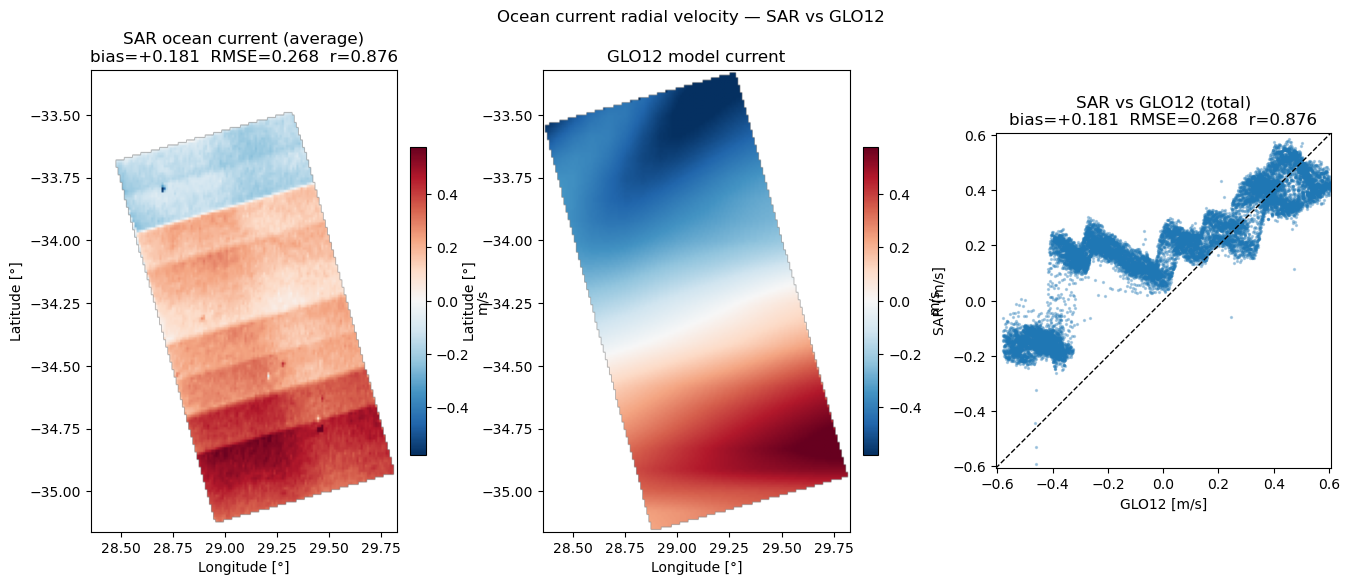


 Burst  bias [m/s]  RMSE [m/s]       r
────────────────────────────────────────
  merged     +0.1795      0.2691  0.8713
────────────────────────────────────────
 total     +0.1808      0.2680  0.8760


In [24]:
plot_comparison(result_scene22, overlap='average')

Merging SAR …
Merging GLO12 …


c:\Users\ottos\Documents\Geomatik\2. Sem\ocean_current_retrieval\scripts\rvl_pipeline.py:1052: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


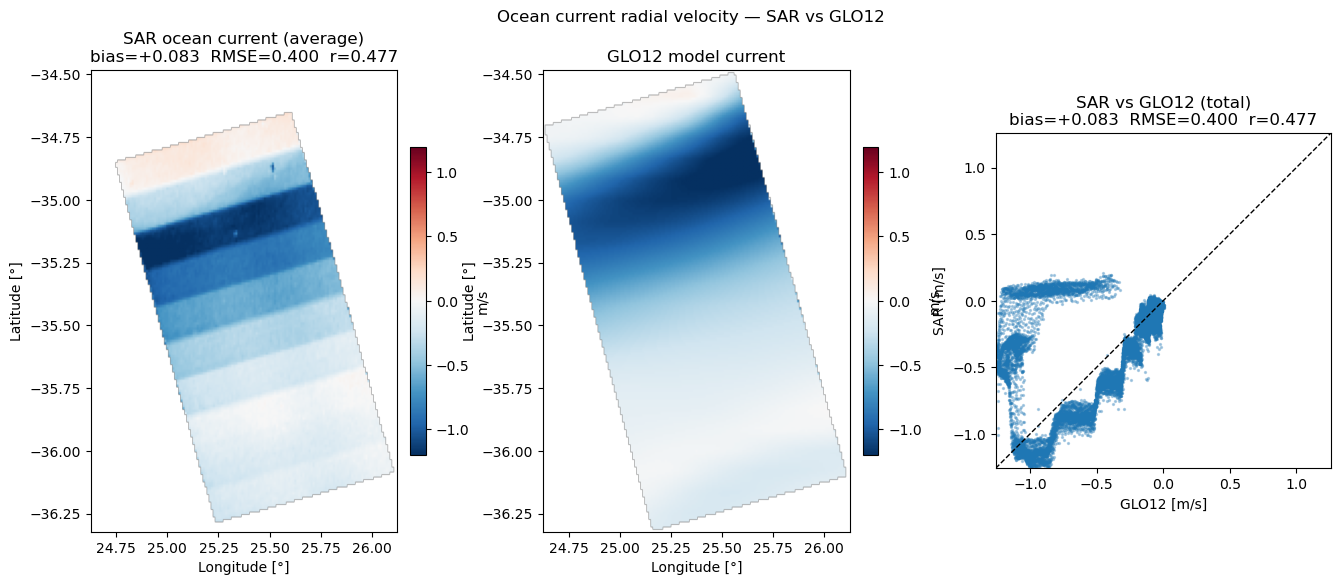


 Burst  bias [m/s]  RMSE [m/s]       r
────────────────────────────────────────
  merged     +0.0890      0.4044  0.4699
────────────────────────────────────────
 total     +0.0828      0.3997  0.4769


In [25]:
plot_comparison(result_scene32, overlap='average')

In [ ]:
import sys; sys.path.insert(0, '.')
from scripts.s1_io import find_safe_files, parse_annotation
from scripts.s1_aux import apply_poeorb

files  = find_safe_files(SLC_SAFE, 'iw1', 'vv')
annot  = parse_annotation(files['annotation'])

lpb = annot.lines_per_burst
print(f'linesPerBurst = {lpb}')
print(f'samplesPerBurst = {annot.samples_per_burst}')
print()
for b in annot.bursts:
    expected_row = b.idx * lpb
    # byte_offset / (2 bytes/component * 2 components * samples_per_burst)
    tiff_row = b.byte_offset // (4 * annot.samples_per_burst)
    print(f'Burst {b.idx:2d}: byte_offset={b.byte_offset:>12d}  '
        f'implied_row={tiff_row:>6d}  expected_row={expected_row:>6d}  '
        f'diff={tiff_row - expected_row:>4d}')

In [44]:
ds = run_analysis(SCENE_IDX, SUBSWATH, BURST_IDX, POL, compute_rvl=True)

All paths exist: True


TypeError: 'bool' object is not callable

In [ ]:
fig, ax = plt.subplots(2,1)
ax[0].imshow(ds["f_dc"])
ax[1].imshow(ds["p1_angle"])

In [27]:
ocn_prod = xr.open_dataset('../data/sentinel-1/scene1/S1A_IW_OCN.SAFE/measurement/s1a-iw-ocn-vv-20260205t165251-20260205t165322-063086-07EAEF-001.nc')

In [28]:
dc_obs = ocn_prod['rvlDcObs']
dc_geo = ocn_prod['rvlDcGeo']
dc_miss = ocn_prod['rvlDcMiss']

dc_corr = dc_obs-dc_geo-dc_miss

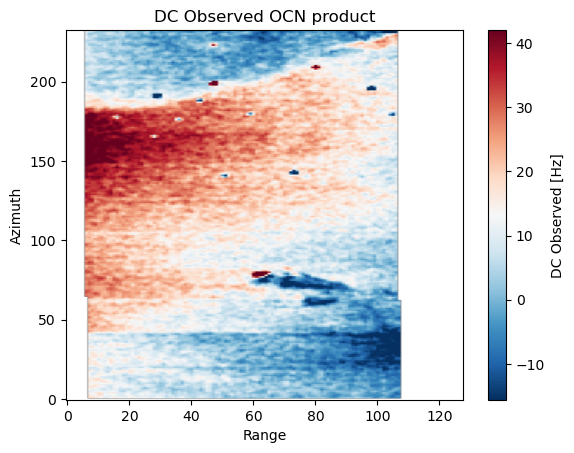

In [41]:
fig, ax = plt.subplots()
img =ax.imshow(dc_obs.values[...,0], vmin=np.nanquantile(dc_obs.values[...,0], 0.01), vmax=np.nanquantile(dc_obs.values[...,0], 0.99), aspect='auto', cmap='RdBu_r')
ax.set_title('DC Observed OCN product')
ax.set_xlabel('Range')
ax.set_ylabel('Azimuth')
plt.colorbar(img,label='DC Observed [Hz]')
ax.invert_yaxis()